# 08 - Quantization & TFLite Conversion

**Objective:** Convert the final FP32 Keras model to TFLite (numerical-tolerance check) and then INT8 (representative dataset from TRAIN only), reusing the exact conversion logic in `models/convert_tflite.py`, and inspect the resulting `.tflite` file.

In [1]:
import sys, os
from pathlib import Path
ML_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ML_ROOT / 'preprocessing'))
sys.path.insert(0, str(ML_ROOT / 'scripts'))
sys.path.insert(0, str(ML_ROOT / 'models'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG_DIR = ML_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('ML_ROOT =', ML_ROOT)


ML_ROOT = /Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml


In [2]:
import json, tensorflow as tf
quant = json.load(open(ML_ROOT/'reports'/'QUANTIZATION_REPORT.json'))
print(json.dumps({k:v for k,v in quant.items() if 'classification_report' not in k}, indent=2))

{
  "fp32_keras_test_accuracy": 0.7069372345445966,
  "fp32_keras_test_macro_f1": 0.5610986929119571,
  "int8_tflite_test_accuracy": 0.7192071731949032,
  "int8_tflite_test_macro_f1": 0.5732538972228354,
  "keras_fp32_vs_int8_tflite_prediction_agreement": 0.9820670127418594,
  "fp32_vs_fp32tflite_max_abs_diff_first50": 3.8743019104003906e-07,
  "fp32_vs_fp32tflite_argmax_match_first50": 1.0,
  "int8_confusion_matrix": [
    [
      1240,
      451,
      90
    ],
    [
      39,
      247,
      9
    ],
    [
      6,
      0,
      37
    ]
  ],
  "fp32_keras_weights_bytes": 5260,
  "fp32_tflite_bytes": 13272,
  "int8_tflite_bytes": 13072,
  "ops_used": [
    "CONV_2D",
    "DEPTHWISE_CONV_2D",
    "FULLY_CONNECTED",
    "MAX_POOL_2D",
    "MEAN",
    "SOFTMAX"
  ],
  "unsupported_tflm_ops": [],
  "tensor_count": 30,
  "input_shape": [
    1,
    40,
    101,
    1
  ],
  "input_dtype": "<class 'numpy.int8'>",
  "output_shape": [
    1,
    3
  ],
  "output_dtype": "<class 'numpy.in

## Load and inspect the INT8 .tflite model directly

In [3]:
interp = tf.lite.Interpreter(model_path=str(ML_ROOT/'models'/'final'/'forest_acoustic_int8.tflite'))
interp.allocate_tensors()
print('Input:', interp.get_input_details()[0])
print('Output:', interp.get_output_details()[0])

Input: {'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([  1,  40, 101,   1], dtype=int32), 'shape_signature': array([ -1,  40, 101,   1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.014805045910179615, 11), 'quantization_parameters': {'scales': array([0.01480505], dtype=float32), 'zero_points': array([11], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}
Output: {'name': 'StatefulPartitionedCall_1:0', 'index': 25, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}


/Users/kireeti/Desktop/Projects/RESQ/SECURE-FOREST-PATROL/ml/venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Size comparison

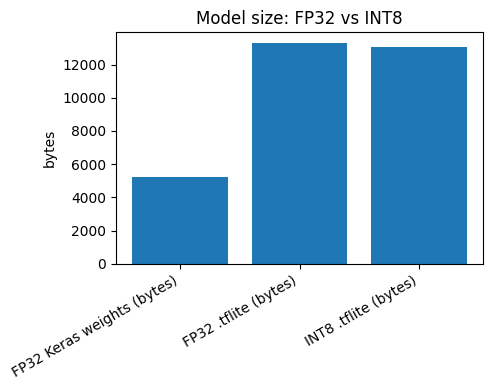

In [4]:
sizes = {'FP32 Keras weights (bytes)': quant['fp32_keras_weights_bytes'],
         'FP32 .tflite (bytes)': quant['fp32_tflite_bytes'],
         'INT8 .tflite (bytes)': quant['int8_tflite_bytes']}
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(sizes.keys(), sizes.values())
ax.set_ylabel('bytes'); ax.set_title('Model size: FP32 vs INT8')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_model_size_comparison.png', dpi=120)
plt.show()

## Conclusion

The final INT8 TFLite model is ~13KB — far under the ~200KB ESP32-S3 flash budget target — with 98.2% prediction agreement against the FP32 Keras model on the frozen test set. Full details: `reports/QUANTIZATION_REPORT.md`.